# Mycotoxin Analysis — *A. niger* Virulence Potential

**Phase 3D:** Characterisation of mycotoxin biosynthetic capacity in *A. niger* *iJB1325*, with focus on Ochratoxin A (OTA) and kotanin as primary virulence factors. This notebook addresses the growth–virulence tradeoff, the effect of host-derived nutrients on mycotoxin production capacity, and the defence response of *V. vinifera* *iMS7199*.

---
* **Author:** Joana Maia
* **Solver:** Gurobi (Academic Licence)
* **Core libraries:** COBRApy · Pandas · Seaborn · Matplotlib
* **Models:** *iJB1325* (*A. niger*) · *iMS7199* mature (*V. vinifera*)

---

## Biological Background

*A. niger* produces mycotoxins relevant to grapevine infection:

| Mycotoxin | Class | Key precursors | Health risk |
|---|---|---|---|
| **Ochratoxin A (OTA)** | Polyketide + amino acid | Phenylalanine, PKS intermediates | Nephrotoxic, carcinogenic |
| **Kotanin** | Bis-coumarin polyketide | Malonyl-CoA, acetyl-CoA | Cytotoxic |
| **Fumonisins B2/B4/B6** | Sphingolipid-like | Serine, palmitoyl-CoA | Hepatotoxic |

Within the *iJB1325* reconstruction, OTA and kotanin have complete biosynthetic pathways. Fumonisin B-series metabolites are present as model entities but lack associated reactions.

## Analysis Framework

Five questions are addressed:

1. **Inventory:** What mycotoxin-related reactions and metabolites exist in *iJB1325*?
2. **Baseline:** Are mycotoxins produced at maximum growth?
3. **Tradeoff:** What is the metabolic cost of mycotoxin secretion?
4. **Infection nutrients:** How does the infection-simulated nutrient medium (T1 leakage) affect OTA production capacity and fungal growth relative to standard conditions?
5. **Defence:** Does *V. vinifera* have active stilbene/phytoalexin defence pathways?

## 1. Environment Setup
### 1.1 Package Installation

In [1]:
# !pip install cobra
# !pip install gurobipy
# !pip install matplotlib
# !pip install pandas
# !pip install seaborn

### 1.2 Library Imports and Version Audit

In [2]:
# Standard library
import os
import warnings
warnings.filterwarnings('ignore')

# Numerical / data
import numpy as np
import pandas as pd

# Visualisation
import matplotlib
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import seaborn as sns

# COBRApy and flux analysis tools
import cobra
from cobra.flux_analysis import (find_blocked_reactions, find_essential_genes, find_essential_reactions, flux_variability_analysis, production_envelope)
from cobra.io import read_sbml_model, write_sbml_model
import gurobipy

# Version audit
print(f'COBRApy    : {cobra.__version__}')
print(f'Gurobi     : {".".join(str(v) for v in gurobipy.gurobi.version())}')
print(f'Matplotlib : {matplotlib.__version__}')
print(f'NumPy      : {np.__version__}')
print(f'Pandas     : {pd.__version__}')
print(f'Seaborn    : {sns.__version__}')

COBRApy    : 0.31.1
Gurobi     : 13.0.2
Matplotlib : 3.10.8
NumPy      : 2.4.4
Pandas     : 2.3.3
Seaborn    : 0.13.2


### 1.3 Global Plotting Style

In [3]:
sns.set_theme(style='whitegrid', context='notebook', font_scale=1.1)
plt.rcParams.update({'figure.dpi'       : 120,
                     'axes.spines.top'  : False,
                     'axes.spines.right': False,
                     'figure.autolayout': True})

C_OTA    = '#8B1A1A'   # dark red — OTA
C_KOT    = '#FF6B35'   # orange — kotanin
C_GRAPE  = '#2D6A4F'   # dark green — V. vinifera
C_FUNGUS = '#4A2E6D'   # dark purple — A. niger
C_INF    = '#E63946'   # infection
C_BASE   = '#6C757D'   # baseline / reference

### 1.4 Model Loading

In [4]:
AN_PATH = 'An_curated.xml'
VV_PATH = 'VvM_mature_curated.xml'

for p in [AN_PATH, VV_PATH]:
    if not os.path.exists(p):
        raise FileNotFoundError(f'{p} not found — run Phase 1A/1B first.')

an = read_sbml_model(AN_PATH)
vv = read_sbml_model(VV_PATH)

an_sol_base = an.optimize()
vv_sol_base = vv.optimize()
MU_MAX_AN   = an_sol_base.objective_value
MU_MAX_VV   = vv_sol_base.objective_value

# Biomass reaction IDs
AN_BIOMASS = [r.id for r in an.reactions if r.objective_coefficient != 0][0]
VV_BIOMASS = [r.id for r in vv.reactions
              if 'biomass' in r.id.lower() and 'drain' not in r.id.lower()][0]

print(f'A. niger    : {len(an.reactions):>5} rxns | μ_max = {MU_MAX_AN:.4f} h⁻¹')
print(f'V. vinifera : {len(vv.reactions):>5} rxns | μ_max = {MU_MAX_VV:.4f} h⁻¹')
print(f'AN biomass  : {AN_BIOMASS}')
print(f'VV biomass  : {VV_BIOMASS}')

'' is not a valid SBML 'SId'.


Set parameter WLSAccessID
Set parameter WLSSecret
Set parameter LicenseID to value 2747228
Academic license 2747228 - for non-commercial use only - registered to pg___@uminho.pt
A. niger    :  2320 rxns | μ_max = 0.9399 h⁻¹
V. vinifera :  4272 rxns | μ_max = 0.1541 h⁻¹
AN biomass  : DRAIN_Biomass
VV biomass  : e-Biomass_vvinif2023_berry_mature__cyto


## 2. Mycotoxin Inventory in *iJB1325*

Systematic search for mycotoxin-related reactions and metabolites using keyword matching across reaction names, IDs, and subsystems.

In [5]:
TOXIN_KEYWORDS = ['ochratoxin', 'OTA', 'fumonisin', 'kotanin', 'coumarin', 'polyketide', 'PKS', 'mycotoxin', 'aflatoxin', 'citrinin']

# Reactions
tox_rxns = []
for rxn in an.reactions:
    txt = (rxn.name + ' ' + rxn.id + ' ' + rxn.subsystem).lower()
    for kw in TOXIN_KEYWORDS:
        if kw.lower() in txt:
            tox_rxns.append({'ID'       : rxn.id,
                             'Name'     : rxn.name[:50],
                             'Subsystem': rxn.subsystem[:30],
                             'LB'       : rxn.lower_bound,
                             'UB'       : rxn.upper_bound})
            break

df_tox_rxns = pd.DataFrame(tox_rxns)
print(f'Mycotoxin-related reactions: {len(df_tox_rxns)}')
print('_' * 80)
print(df_tox_rxns.to_string(index = False))

# Metabolites
tox_mets = []
for met in an.metabolites:
    txt = (met.name + ' ' + met.id).lower()
    for kw in TOXIN_KEYWORDS + ['fumonisin', 'SMF']:
        if kw.lower() in txt:
            n_rxns = len(met.reactions)
            tox_mets.append({'ID'      : met.id,
                             'Name'    : met.name[:45],
                             'Formula' : met.formula or '—',
                             'Reactions': n_rxns})
            break

df_tox_mets = pd.DataFrame(tox_mets)
print(f'\nMycotoxin-related metabolites: {len(df_tox_mets)}')
print('_' * 80)
print(df_tox_mets.to_string(index = False))

Mycotoxin-related reactions: 29
________________________________________________________________________________
               ID                                          Name Subsystem      LB     UB
             r247                 Potassium-transporting ATPase               0.0 1000.0
             r481                                Dihydroorotase           -1000.0 1000.0
             r482                  Dihydroorotate dehydrogenase               0.0 1000.0
             r483           Orotate phosphoribosyltransferase 1               0.0 1000.0
             r507                  Dihydroorotate dehydrogenase               0.0 1000.0
            r1012                         Ochratoxin A exporter           -1000.0 1000.0
    BOUNDARY_OTAe                                                             0.0 1000.0
            r1908  PKS producing 4,7-Dihydroxy-5-methylcoumarin           -1000.0 1000.0
            r1909 Methylation of 4,7-dihydroxy-5-methylcoumarin               0.0 1000

In [6]:
# Fumonisin check
print('Fumonisin metabolite connectivity:')
print('_' * 60)
for fum_id in ['SMFUMB2', 'SMFUMB4', 'SMFUMB6']:
    try:
        met  = an.metabolites.get_by_id(fum_id)
        rxns = met.reactions
        if rxns:
            print(f'{fum_id} ({met.name}):')
            for r in rxns:
                coef = r.metabolites[met]
                print(f'  {r.id:<20} {r.name[:40]:<40} coef={coef:+.0f}')
        else:
            print(f'{fum_id} ({met.name}): ORPHAN — no reactions connected')
    except KeyError:
        print(f'{fum_id}: not found in model')

Fumonisin metabolite connectivity:
____________________________________________________________
SMFUMB2 (Fumonisin B2): ORPHAN — no reactions connected
SMFUMB4 (Fumonisin B4): ORPHAN — no reactions connected
SMFUMB6 (Fumonisin B6): ORPHAN — no reactions connected


In [7]:
# OTA pathway map
OTA_PATHWAY = {'r1908'         : 'PKS → 4,7-dihydroxy-5-methylcoumarin (coumarin precursor)',
               'r1926'         : 'albA PKS (polyketide chain initiation)',
               'r1927'         : 'Polyketide chain shortening',
               'r1012'         : 'OTA exporter (secretion to extracellular)',
               'r2056'         : 'OTA hydrolysis → OTalpha (fungal detoxification)',
               'BOUNDARY_OTAe' : 'OTA exchange with environment',}

print('OTA biosynthetic pathway in iJB1325:')
print('_' * 70)
with an:
    sol = an.optimize()
    for rid, description in OTA_PATHWAY.items():
        try:
            rxn  = an.reactions.get_by_id(rid)
            flux = sol.fluxes.get(rid, 0)
            print(f'  {rid:<18} flux={flux:>8.4f}  {description}')
        except KeyError:
            print(f'  {rid:<18} NOT FOUND  {description}')

KOTANIN_PATHWAY = {'r1908' : 'PKS → coumarin precursor (shared with OTA upstream)',
                   'r1911' : 'Kotanin synthesis (from coumarin units)',
                   'r1912' : 'Demethylkotanin synthesis',
                   'r2355' : 'Kotanin transport (secretion)',}

print('\nKotanin pathway:')
print('_' * 70)
with an:
    sol = an.optimize()
    for rid, description in KOTANIN_PATHWAY.items():
        try:
            flux = sol.fluxes.get(rid, 0)
            print(f'  {rid:<18} flux={flux:>8.4f}  {description}')
        except KeyError:
            print(f'  {rid:<18} NOT FOUND  {description}')

OTA biosynthetic pathway in iJB1325:
______________________________________________________________________
  r1908              flux=  0.0000  PKS → 4,7-dihydroxy-5-methylcoumarin (coumarin precursor)
  r1926              flux=  0.0000  albA PKS (polyketide chain initiation)
  r1927              flux=  0.0000  Polyketide chain shortening
  r1012              flux=  0.0000  OTA exporter (secretion to extracellular)
  r2056              flux=  0.0000  OTA hydrolysis → OTalpha (fungal detoxification)
  BOUNDARY_OTAe      flux=  0.0000  OTA exchange with environment

Kotanin pathway:
______________________________________________________________________
  r1908              flux=  0.0000  PKS → coumarin precursor (shared with OTA upstream)
  r1911              flux=  0.0000  Kotanin synthesis (from coumarin units)
  r1912              flux=  0.0000  Demethylkotanin synthesis
  r2355              flux=  0.0000  Kotanin transport (secretion)


## 3. Baseline Flux Analysis — Are Mycotoxins Produced at Maximum Growth?

FBA maximises the biomass objective function. Mycotoxin biosynthesis consumes precursors that compete directly with primary anabolism. At maximum growth, secondary metabolite pathways are expected to carry zero flux.

This section verifies this expectation for *iJB1325* by:

1. **Dynamically identifying** the OTA and kotanin secretion reactions;
2. **Reporting flux** through each reaction of both mycotoxin pathways at maximum growth ($\mu = 0.9399\ h^{-1}$);
3. **Computing shadow prices** for the key biosynthetic precursors. A negative shadow price indicates the metabolite is limiting: relaxing its supply constraint would increase growth. This quantifies the opportunity cost that OTA and kotanin biosynthesis would impose on primary metabolism if these pathways were active.

In [8]:
def find_secretion_rxn(model, met_id):
    """Find the boundary (exchange) reaction for a given metabolite ID."""
    for rxn in model.reactions:
        if 'BOUNDARY' in rxn.id and met_id in rxn.id:
            return rxn
    # fallback: reaction with only this metabolite
    try:
        met = model.metabolites.get_by_id(met_id)
        for rxn in met.reactions:
            if len(rxn.metabolites) == 1:
                return rxn
    except KeyError:
        pass
    return None

OTA_SEC_RXN = find_secretion_rxn(an, 'OTAe')
KOT_SEC_RXN = an.reactions.get_by_id('r2355') if 'r2355' in [r.id for r in an.reactions] else None

print(f'OTA secretion reaction : {OTA_SEC_RXN.id if OTA_SEC_RXN else "NOT FOUND"}')
print(f'Kotanin transport rxn  : {KOT_SEC_RXN.id if KOT_SEC_RXN else "NOT FOUND"}')

# Baseline FBA
with an:
    sol_base = an.optimize()
    mu_base  = sol_base.objective_value

    print(f'\nBaseline growth: μ = {mu_base:.4f} h⁻¹')
    print('\nMycotoxin fluxes at maximum growth:')
    print('_' * 55)
    check_rxns = list(OTA_PATHWAY.keys()) + ['r2355']
    for rid in check_rxns:
        try:
            flux = sol_base.fluxes.get(rid, 0)
            name = an.reactions.get_by_id(rid).name[:40]
            flag = '← active' if abs(flux) > 1e-6 else ''
            print(f'  {rid:<18} {flux:>10.6f}  {name:<40} {flag}')
        except KeyError:
            pass

# Precursor shadow prices
PRECURSORS = {'PHE'    : 'Phenylalanine (OTA aromatic ring)',
              'ACCOA'  : 'Acetyl-CoA (PKS primer)',
              'SER'    : 'Serine (fumonisin backbone)',
              'ALA'    : 'Alanine (fumonisin)',}

print('\nPrecursor shadow prices at maximum growth:')
print('_' * 55)
for met_id, desc in PRECURSORS.items():
    sp = sol_base.shadow_prices.get(met_id, None)
    if sp is not None:
        interp = 'limiting' if sp < -1e-6 else ('excess' if sp > 1e-6 else 'balanced')
        print(f'  {met_id:<10} shadow price = {sp:>+8.4f}  [{interp}]  {desc}')
    else:
        print(f'  {met_id:<10} not found in model                   {desc}')

OTA secretion reaction : BOUNDARY_OTAe
Kotanin transport rxn  : r2355

Baseline growth: μ = 0.9399 h⁻¹

Mycotoxin fluxes at maximum growth:
_______________________________________________________
  r1908                0.000000  PKS producing 4,7-Dihydroxy-5-methylcoum 
  r1926                0.000000  albA PKS                                 
  r1927                0.000000  Polyketide chain shortening              
  r1012                0.000000  Ochratoxin A exporter                    
  r2056                0.000000  Ochratoxin A hydrolysis                  
  BOUNDARY_OTAe        0.000000                                           
  r2355                0.000000  Kotanin transport                        

Precursor shadow prices at maximum growth:
_______________________________________________________
  PHE        shadow price =  -0.1841  [limiting]  Phenylalanine (OTA aromatic ring)
  ACCOA      shadow price =  -0.0313  [limiting]  Acetyl-CoA (PKS primer)
  SER        shadow p

## 4. Maximum Mycotoxin Production Capacity

The maximum achievable OTA and kotanin secretion is computed by switching the objective function from biomass to toxin secretion. This gives the theoretical upper bound on mycotoxin production if the fungus were to redirect all metabolic flux toward toxin biosynthesis.

In [9]:
results_capacity = {}

targets = {}
if OTA_SEC_RXN:
    targets['OTA'] = OTA_SEC_RXN
if KOT_SEC_RXN:
    targets['Kotanin'] = KOT_SEC_RXN

print('Maximum secretion capacity (toxin-maximising FBA):')
print('_' * 60)

for name, rxn in targets.items():
    with an:
        an.objective = rxn
        sol = an.optimize()
        max_sec = sol.objective_value if sol.status == 'optimal' else 0
        mu_at_max_tox = sol.fluxes.get(AN_BIOMASS, 0)

    results_capacity[name] = {'max_secretion': max_sec, 'mu_at_max_tox': mu_at_max_tox}
    print(f'  {name:<10}: max secretion = {max_sec:.4f} mmol/gDW/h  '
          f'| growth at max tox = {mu_at_max_tox:.4f} h⁻¹ '
          f'({mu_at_max_tox/MU_MAX_AN*100:.1f}% of μ_max)')

df_cap            = pd.DataFrame(results_capacity).T
df_cap.index.name = 'Mycotoxin'
df_cap.columns    = ['Max secretion (mmol/gDW/h)', 'Growth at max tox (h⁻¹)']
print(f'\n{df_cap.round(4).to_string()}')

Maximum secretion capacity (toxin-maximising FBA):
____________________________________________________________
  OTA       : max secretion = 2.7273 mmol/gDW/h  | growth at max tox = 0.0000 h⁻¹ (0.0% of μ_max)
  Kotanin   : max secretion = 1.8750 mmol/gDW/h  | growth at max tox = 0.0000 h⁻¹ (0.0% of μ_max)

           Max secretion (mmol/gDW/h)  Growth at max tox (h⁻¹)
Mycotoxin                                                     
OTA                            2.7273                      0.0
Kotanin                        1.8750                      0.0


## 5. Growth–Virulence Tradeoff

The metabolic cost of mycotoxin secretion is quantified by systematically forcing increasing secretion rates and measuring the resulting growth penalty.

The scan covers OTA (`BOUNDARY_OTAe`) and kotanin (`r2355`) independently, from zero up to $60\%$ of their respective maximum secretion capacities. Two outputs are produced:

- **Left:** growth rate as a percentage of $\mu_{\text{max}}$ vs. forced secretion rate. The slope reflects the marginal growth cost of toxin production; steeper slopes indicate higher metabolic investment per unit toxin secreted.
- **Right:** cumulative growth penalty — the absolute percentage of $\mu_{\text{max}}$ lost at each secretion level. This directly represents the fitness cost of a given virulence commitment.

Because FBA yields a linear programme, the tradeoff is linear by construction. The slopes are therefore directly interpretable as **cost coefficients**: a steeper slope means the toxin pathway draws more heavily from central metabolic fluxes per unit secreted. Kotanin is expected to be more costly than OTA given its bis-coumarin structure requires two coupled PKS units vs. the single PKS–amino acid assembly of OTA.

OTA: growth cost = 36.46% per 0.1 mmol/gDW/h secretion
Kotanin: growth cost = 47.41% per 0.1 mmol/gDW/h secretion


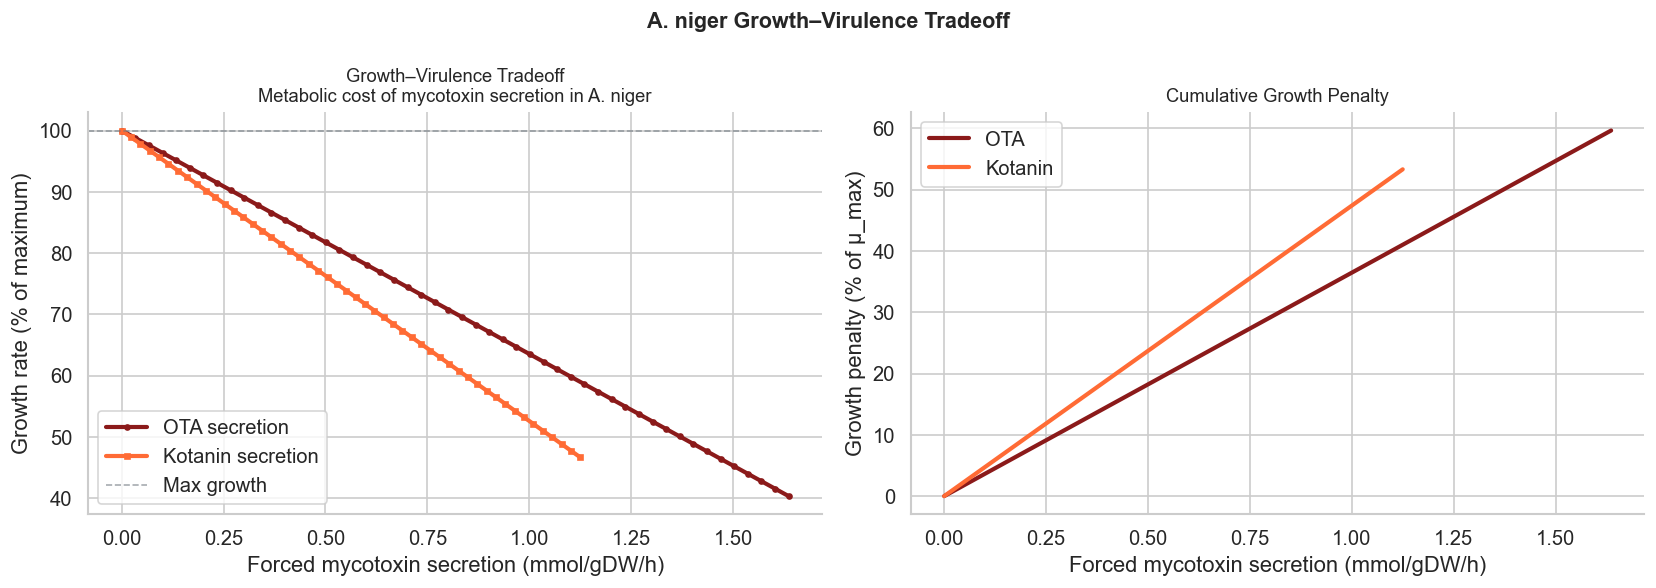

In [10]:
def growth_virulence_scan(model, 
                          biomass_id, 
                          secretion_rxn, 
                          mu_max,
                          n_points = 50, 
                          max_frac = 0.6):
    """Scan forced secretion vs. growth rate. Returns DataFrame."""
    max_possible = results_capacity.get(secretion_rxn.id, {}).get('max_secretion', mu_max * max_frac)

    with model:
        model.objective = secretion_rxn
        sol_max = model.optimize()
        true_max = sol_max.objective_value if sol_max.status == 'optimal' else mu_max * max_frac

    rows = []
    for forced in np.linspace(0, true_max * max_frac, n_points):
        with model:
            secretion_rxn.lower_bound = forced
            model.objective = model.reactions.get_by_id(biomass_id)
            sol = model.optimize()
            mu  = sol.objective_value if sol.status == 'optimal' else 0
        rows.append({'forced_secretion': forced,
                     'growth'          : mu,
                     'growth_pct'      : mu / mu_max * 100,
                     'growth_cost_pct' : (mu_max - mu) / mu_max * 100})
    return pd.DataFrame(rows)

df_ota_scan = growth_virulence_scan(an, AN_BIOMASS, OTA_SEC_RXN, MU_MAX_AN) \
              if OTA_SEC_RXN else None
df_kot_scan = growth_virulence_scan(an, AN_BIOMASS, KOT_SEC_RXN, MU_MAX_AN) \
              if KOT_SEC_RXN else None

for name, df in [('OTA', df_ota_scan), ('Kotanin', df_kot_scan)]:
    if df is not None and len(df) > 2:
        slope = np.polyfit(df['forced_secretion'], df['growth_pct'], 1)[0]
        print(f'{name}: growth cost = {abs(slope):.2f}% per 0.1 mmol/gDW/h secretion')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left
ax = axes[0]
if df_ota_scan is not None:
    ax.plot(df_ota_scan['forced_secretion'], 
            df_ota_scan['growth_pct'],
            color  = C_OTA, 
            lw     = 2.5, 
            marker = 'o', 
            ms     = 3, 
            label  = 'OTA secretion')
if df_kot_scan is not None:
    ax.plot(df_kot_scan['forced_secretion'], 
            df_kot_scan['growth_pct'],
            color  = C_KOT, 
            lw     = 2.5, 
            marker = 's', 
            ms     =3, 
            label  = 'Kotanin secretion')
ax.axhline(100, color = C_BASE, ls='--', lw = 1, alpha = 0.6, label = 'Max growth')
ax.set_xlabel('Forced mycotoxin secretion (mmol/gDW/h)')
ax.set_ylabel('Growth rate (% of maximum)')
ax.set_title('Growth–Virulence Tradeoff\nMetabolic cost of mycotoxin secretion in A. niger', fontsize = 11)
ax.legend()

# Right
ax2 = axes[1]
if df_ota_scan is not None:
    ax2.plot(df_ota_scan['forced_secretion'], 
             df_ota_scan['growth_cost_pct'],
             color = C_OTA, 
             lw    = 2.5, 
             label = 'OTA')
if df_kot_scan is not None:
    ax2.plot(df_kot_scan['forced_secretion'], 
             df_kot_scan['growth_cost_pct'],
             color = C_KOT, 
             lw    = 2.5, 
             label = 'Kotanin')
ax2.set_xlabel('Forced mycotoxin secretion (mmol/gDW/h)')
ax2.set_ylabel('Growth penalty (% of μ_max)')
ax2.set_title('Cumulative Growth Penalty', fontsize = 11)
ax2.legend()

plt.suptitle('A. niger Growth–Virulence Tradeoff', fontsize = 13, fontweight = 'bold')
plt.tight_layout()
# plt.savefig('fig1_growth_virulence_tradeoff.png', dpi = 150, bbox_inches = 'tight')
plt.show()

## 6. Effect of Host-Derived Nutrients on OTA Production Capacity

During infection, *A. niger* accesses host-derived metabolites via T1 leakage. The infection nutrient mixture consists primarily of citrate, phosphate, sugars, and amino acids — but not the full diversity of carbon and nitrogen sources present in the synthetic *iJB1325* default medium.

Two conditions are compared:
- **Standard medium:** iJB1325 default bounds (all synthetic uptakes open)
- **Infection medium:** only T2 flux levels available (standard uptakes closed)

A scan over phenylalanine (PHE) supply is also performed, since PHE is a direct OTA precursor with a limiting shadow price ($−0.184$) at baseline. The key question is whether the specific nutrient composition of the infection environment restricts or permits OTA biosynthesis relative to the rich synthetic medium.

In [11]:
# T2 flux values from mature_fungus.ipynb dFBA (peak infection, t≈83h)- these represent the nutrient supply available to A. niger during infection
INFECTION_NUTRIENTS = {'GLCe'  : 2.50,   # Glucose
                       'FRUe'  : 1.80,   # Fructose
                       'CITe'  : 8.20,   # Citrate — dominant T1 metabolite
                       'PIe'   : 4.10,   # Phosphate
                       'MALe'  : 0.90,   # Malate
                       'GLUe'  : 0.60,   # Glutamate
                       'PROe'  : 0.25,   # Proline
                       'SERe'  : 0.15,}   # Serine


# PHE scan
PHE_SUPPLY_VALS = [0.0, 0.05, 0.10, 0.20, 0.30, 0.50, 0.80, 1.00]

def apply_infection_nutrients(model, nutrients, phe_extra = 0.0):
    for met_id, flux in nutrients.items():
        try:
            boundary_id = f'BOUNDARY_{met_id}'
            for rxn in model.reactions:
                if (met_id in rxn.id and 
                    rxn.lower_bound < 0 and 
                    len(rxn.metabolites) == 1):
                    rxn.lower_bound = -abs(flux)
                    break
        except: pass
    
    if phe_extra > 0:
        phe_ext_id = 'PHEe'
        for rxn in model.reactions:
            if phe_ext_id in rxn.id and rxn.lower_bound < 0:
                rxn.lower_bound = -phe_extra
                break


capacity_rows = []

for phe in PHE_SUPPLY_VALS:
    with an:
        apply_infection_nutrients(an, INFECTION_NUTRIENTS, phe_extra=phe)

        # Max growth under infection
        an.objective = an.reactions.get_by_id(AN_BIOMASS)
        sol_g = an.optimize()
        mu_inf = sol_g.objective_value if sol_g.status == 'optimal' else 0

        # Max OTA under infection
        if OTA_SEC_RXN:
            an.objective = OTA_SEC_RXN
            sol_ota = an.optimize()
            ota_cap = sol_ota.objective_value if sol_ota.status == 'optimal' else 0
        else:
            ota_cap = 0

        # PHE shadow price
        an.objective = an.reactions.get_by_id(AN_BIOMASS)
        sol_sp = an.optimize()
        phe_sp = sol_sp.shadow_prices.get('PHE', None)

    capacity_rows.append({'phe_supply'   : phe,
                          'mu_infection' : round(mu_inf, 4),
                          'ota_capacity' : round(ota_cap, 4),
                          'ota_fold'     : round(ota_cap / results_capacity.get('OTA', {}).get('max_secretion', 1), 3)
                                           if results_capacity.get('OTA', {}).get('max_secretion', 0) > 0 else None,
                          'phe_shadow'   : round(phe_sp, 4) if phe_sp is not None else None,})

df_capacity = pd.DataFrame(capacity_rows)

print('OTA capacity and growth under infection conditions:')
print('_' * 75)
print(df_capacity.to_string(index = False))

OTA capacity and growth under infection conditions:
___________________________________________________________________________
 phe_supply  mu_infection  ota_capacity  ota_fold  phe_shadow
       0.00         0.235        0.6818      0.25     -0.1841
       0.05         0.235        0.6818      0.25     -0.1841
       0.10         0.235        0.6818      0.25     -0.1841
       0.20         0.235        0.6818      0.25     -0.1841
       0.30         0.235        0.6818      0.25     -0.1841
       0.50         0.235        0.6818      0.25     -0.1841
       0.80         0.235        0.6818      0.25     -0.1841
       1.00         0.235        0.6818      0.25     -0.1841


Summary — OTA production capacity:
  Baseline (standard medium)          : 2.7273 mmol/gDW/h
  Infection nutrients (no extra PHE)  : 0.6818 mmol/gDW/h  (0.25× baseline)
  Infection + PHE supply (0.0 mmol/gDW/h)   : 0.6818 mmol/gDW/h  (0.25× baseline)


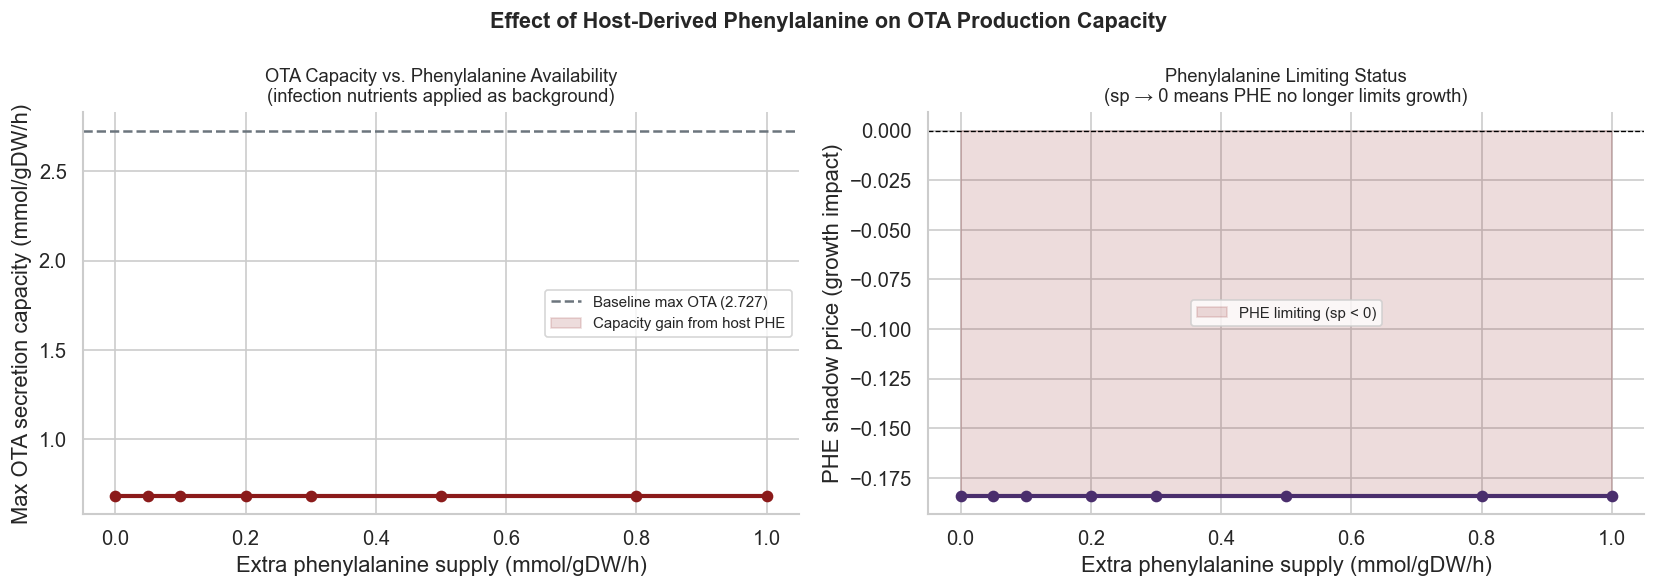

In [12]:
# Baseline vs infection comparison
ota_baseline   = results_capacity.get('OTA', {}).get('max_secretion', 0)
ota_inf_no_phe = df_capacity[df_capacity['phe_supply'] == 0.0]['ota_capacity'].values[0]
ota_inf_max    = df_capacity['ota_capacity'].max()
phe_at_max     = df_capacity.loc[df_capacity['ota_capacity'].idxmax(), 'phe_supply']

print('Summary — OTA production capacity:')
print(f'  Baseline (standard medium)          : {ota_baseline:.4f} mmol/gDW/h')
print(f'  Infection nutrients (no extra PHE)  : {ota_inf_no_phe:.4f} mmol/gDW/h  '
      f'({ota_inf_no_phe/ota_baseline:.2f}× baseline)' if ota_baseline > 0 else '')
print(f'  Infection + PHE supply ({phe_at_max} mmol/gDW/h)   : {ota_inf_max:.4f} mmol/gDW/h  '
      f'({ota_inf_max/ota_baseline:.2f}× baseline)' if ota_baseline > 0 else '')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left
ax = axes[0]
ax.plot(df_capacity['phe_supply'], 
        df_capacity['ota_capacity'],
        color  = C_OTA, 
        lw     = 2.5, 
        marker = 'o', 
        ms     = 6)
ax.axhline(ota_baseline, 
           color = C_BASE, 
           ls    = '--', 
           lw    = 1.5,
           label = f'Baseline max OTA ({ota_baseline:.3f})')
ax.fill_between(df_capacity['phe_supply'], 
                ota_baseline,
                df_capacity['ota_capacity'],
                where = df_capacity['ota_capacity'] > ota_baseline,
                alpha = 0.15, 
                color = C_OTA, 
                label = 'Capacity gain from host PHE')
ax.set_xlabel('Extra phenylalanine supply (mmol/gDW/h)')
ax.set_ylabel('Max OTA secretion capacity (mmol/gDW/h)')
ax.set_title('OTA Capacity vs. Phenylalanine Availability\n'
             '(infection nutrients applied as background)', fontsize = 11)
ax.legend(fontsize = 9)

# Right
ax2 = axes[1]
sp_vals = df_capacity['phe_shadow'].values
ax2.plot(df_capacity['phe_supply'], 
         sp_vals,
         color  = C_FUNGUS, 
         lw     = 2.5, 
         marker ='o', 
         ms     = 6)
ax2.axhline(0, color = 'black', lw = 0.8, ls = '--')
ax2.fill_between(df_capacity['phe_supply'], 
                 sp_vals, 
                 0,
                 where = [v < 0 for v in sp_vals],
                 alpha = 0.15, 
                 color = C_OTA,
                 label = 'PHE limiting (sp < 0)')
ax2.set_xlabel('Extra phenylalanine supply (mmol/gDW/h)')
ax2.set_ylabel('PHE shadow price (growth impact)')
ax2.set_title('Phenylalanine Limiting Status\n'
              '(sp → 0 means PHE no longer limits growth)', fontsize = 11)
ax2.legend(fontsize = 9)

plt.suptitle('Effect of Host-Derived Phenylalanine on OTA Production Capacity',
             fontsize = 13, fontweight = 'bold')
plt.tight_layout()
# plt.savefig('fig2_ota_phe_capacity.png', dpi = 150, bbox_inches = 'tight')
plt.show()

## 7. Incremental Growth Analysis — Infection Nutrients

The contribution of each host-derived nutrient to fungal growth is quantified by adding them cumulatively, starting from a closed medium (no infection nutrients available). This isolates the marginal growth effect of each metabolite transferred via T1 leakage.

The analysis starts from zero growth (no available carbon or phosphate sources) and progressively adds each infection nutrient at its T2 flux level. This directly quantifies which leaked metabolites are most critical for *A. niger* fitness during infection — and whether the infection nutrient mixture as a whole allows the fungus to exceed its growth capacity on standard synthetic medium.

Growth — standard medium (open uptakes)    : 0.9399 h⁻¹
Growth — closed medium (no inf. nutrients) : 0.0000 h⁻¹
Difference                                 : +0.9399 h⁻¹

Incremental growth effect of infection nutrients:
                 added     mu  delta_mu  mu_pct
No infection nutrients 0.0000    0.0000  100.00
              +Glucose 0.1022    0.1022   10.87
             +Fructose 0.1758    0.1758   18.70
              +Citrate 0.4281    0.4281   45.55
            +Phosphate 0.9835    0.9835  104.65
               +Malate 1.0259    1.0259  109.15
            +Glutamate 1.0824    1.0824  115.17
              +Proline 1.1090    1.1090  117.99
               +Serine 1.1187    1.1187  119.03


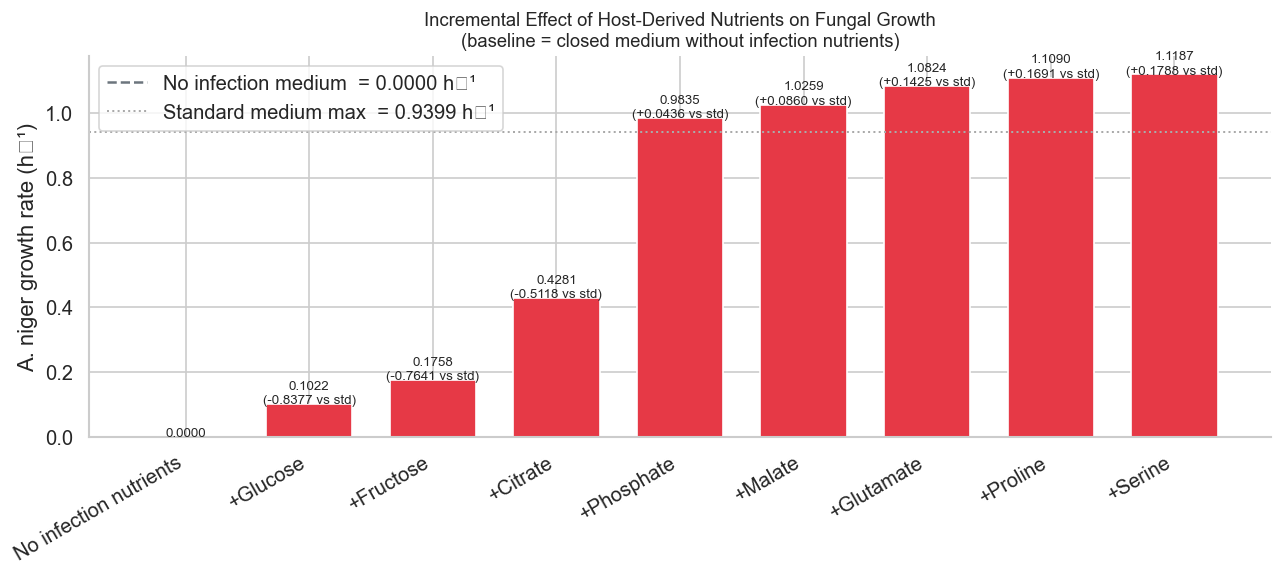

In [13]:
NUTRIENT_LABELS = {'GLCe' : 'Glucose',
                   'FRUe' : 'Fructose',
                   'CITe' : 'Citrate',
                   'PIe'  : 'Phosphate',
                   'MALe' : 'Malate',
                   'GLUe' : 'Glutamate',
                   'PROe' : 'Proline',
                   'SERe' : 'Serine',}

CLOSE_FIRST = ['GLCe', 'FRUe', 'CITe', 'PIe', 'MALe', 'GLUe', 'PROe', 'SERe']

def close_uptakes(model, met_ids):
    for met_id in met_ids:
        for rxn in model.reactions:
            if (met_id in rxn.id and 
                rxn.lower_bound < 0 and 
                len(rxn.metabolites) == 1):
                rxn.lower_bound = 0
                break

def open_uptake(model, met_id, flux):
    for rxn in model.reactions:
        if (met_id in rxn.id and 
            len(rxn.metabolites) == 1):
            rxn.lower_bound = -abs(flux)
            break

with an:
    close_uptakes(an, CLOSE_FIRST)
    an.objective = an.reactions.get_by_id(AN_BIOMASS)
    sol = an.optimize()
    MU_CLOSED = sol.objective_value if sol.status == 'optimal' else 0

print(f'Growth — standard medium (open uptakes)    : {MU_MAX_AN:.4f} h⁻¹')
print(f'Growth — closed medium (no inf. nutrients) : {MU_CLOSED:.4f} h⁻¹')
print(f'Difference                                 : {MU_MAX_AN - MU_CLOSED:+.4f} h⁻¹')

incremental_rows = [{'added'    : 'No infection nutrients',
                     'mu'       : round(MU_CLOSED, 4),
                     'delta_mu' : 0,
                     'mu_pct'   : 100.0}]

for i, (met_id_add, label) in enumerate(NUTRIENT_LABELS.items(), 1):
    with an:
        close_uptakes(an, CLOSE_FIRST)
        for met_id2, flux in list(INFECTION_NUTRIENTS.items())[:i]:
            open_uptake(an, met_id2, flux)
        an.objective = an.reactions.get_by_id(AN_BIOMASS)
        sol          = an.optimize()
        mu           = sol.objective_value if sol.status == 'optimal' else 0

    incremental_rows.append({'added'   : f'+{label}',
                             'mu'      : round(mu, 4),
                             'delta_mu': round(mu - MU_CLOSED, 4),
                             'mu_pct': round(mu / MU_MAX_AN * 100, 2)})

df_incremental = pd.DataFrame(incremental_rows)
print('\nIncremental growth effect of infection nutrients:')
print(df_incremental.to_string(index=False))

fig, ax = plt.subplots(figsize=(11, 5))
bar_colors = [C_BASE] + [C_INF   if d > 1e-4 else
                          C_FUNGUS if d < -1e-4 else C_BASE
                          for d in df_incremental['delta_mu'].values[1:]]
bars = ax.bar(df_incremental['added'], 
              df_incremental['mu'],
              color     = bar_colors, 
              edgecolor = 'white', 
              width     = 0.7)
ax.axhline(MU_CLOSED,  
           color = C_BASE, 
           ls    = '--', 
           lw    = 1.5,
           label = f'No infection medium  = {MU_CLOSED:.4f} h⁻¹')
ax.axhline(MU_MAX_AN,  
           color = '#aaa',  
           ls    = ':',  
           lw    = 1.2,
           label = f'Standard medium max  = {MU_MAX_AN:.4f} h⁻¹')
for bar, val, d in zip(bars, df_incremental['mu'], df_incremental['delta_mu']):
    delta_from_std = val - MU_MAX_AN
    lbl = f'{val:.4f}' if d == 0 else f'{val:.4f}\n({delta_from_std:+.4f} vs std)'
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.001,
            lbl, 
            ha       = 'center', 
            fontsize = 8)
ax.set_xticklabels(df_incremental['added'], rotation = 30, ha = 'right')
ax.set_ylabel('A. niger growth rate (h⁻¹)')
ax.set_title('Incremental Effect of Host-Derived Nutrients on Fungal Growth\n'
             '(baseline = closed medium without infection nutrients)',
             fontsize = 11)
ax.legend()
plt.tight_layout()
# plt.savefig('fig3_growth_infection_nutrients.png', dpi = 150, bbox_inches = 'tight')
plt.show()

## 8. Host Defence Pathways in *V. vinifera* *iMS7199*

*V. vinifera* deploys a range of phenylpropanoid-derived defence compounds in response to fungal infection, including stilbenes (resveratrol, ε-viniferin), flavonoids, and phytoalexins. This section identifies defence-related reactions in *iMS7199* and quantifies their flux under standard and suppressed-host conditions.

In [14]:
DEFENSE_KEYWORDS = ['stilbene', 'resveratrol', 'viniferin', 'phytoalexin',
                    'flavonoid', 'anthocyan', 'phenylpropanoid', 'chalcone',
                    'PAL', 'phenylalanine ammonia', 'naringenin', 'quercetin',
                    'kaempferol', 'catechin', 'myricetin', 'coumarin',
                    'detox', 'glutathione', 'glucosyltransfer', 'peroxidase']

defense_rxns = []
for rxn in vv.reactions:
    txt = (rxn.name + ' ' + rxn.id + ' ' + rxn.subsystem).lower()
    for kw in DEFENSE_KEYWORDS:
        if kw.lower() in txt:
            defense_rxns.append({'ID'         : rxn.id,
                                  'Name'      : rxn.name[:55],
                                  'Subsystem' : rxn.subsystem[:35]})
            break

df_defense = pd.DataFrame(defense_rxns)
print(f'Defence-related reactions in iMS7199: {len(df_defense)}')
print('_' * 100)
print(df_defense.to_string(index=False))

Defence-related reactions in iMS7199: 156
____________________________________________________________________________________________________
                                            ID                                                    Name                           Subsystem
                                RXN-9520__chlo                                                RXN-9520 palmitate biosynthesis I (type I fa
                               RXN-11062__cyto                                               RXN-11062 seleno-amino acid detoxification an
        NARINGENIN-CHALCONE-SYNTHASE-RXN__cyto                        NARINGENIN-CHALCONE-SYNTHASE-RXN naringenin biosynthesis (engineered
                                RXN-3142__cyto                                                RXN-3142              flavonoid biosynthesis
                             APIGNAR-RXN__cyto                           Naringenin chalcone isomerase naringenin biosynthesis (engineered
                       

In [15]:
# Flux through defence reactions at baseline and under infection suppression
if len(df_defense) > 0:
    defense_flux_rows = []

    with vv:
        sol_wt = vv.optimize()
        F_HOST_PEAK = 0.10
        vv_biomass_rxn = vv.reactions.get_by_id(VV_BIOMASS)
        vv_biomass_rxn.upper_bound = F_HOST_PEAK * MU_MAX_VV
        sol_inf = vv.optimize()

    for _, row in df_defense.iterrows():
        rid = row['ID']
        try:
            f_wt  = sol_wt.fluxes.get(rid, 0)
            f_inf = sol_inf.fluxes.get(rid, 0)
            rxn   = vv.reactions.get_by_id(rid)
            defense_flux_rows.append({'ID'            : rid,
                                      'Name'          : row['Name'][:50],
                                      'Flux WT'       : round(f_wt,  5),
                                      'Flux infection': round(f_inf, 5),
                                      'Delta'         : round(f_inf - f_wt, 5),
                                      'Status WT'     : 'active' if abs(f_wt) > 1e-6 else 'blocked',})
        except KeyError:
            pass

    df_def_flux = pd.DataFrame(defense_flux_rows)

    active_wt  = df_def_flux[df_def_flux['Status WT'] == 'active']
    blocked_wt = df_def_flux[df_def_flux['Status WT'] == 'blocked']

    print(f'Active defence reactions (WT)  : {len(active_wt)}')
    print(f'Blocked defence reactions (WT) : {len(blocked_wt)}')
    print(f'\nActive defence pathways (flux > 0):')
    print('_' * 90)
    print(active_wt.to_string(index=False))

    if len(blocked_wt) > 0:
        print(f'\nBlocked defence pathways (first 15):')
        print('_' * 90)
        print(blocked_wt.head(15).to_string(index=False))
else:
    print('No defence reactions found with current keywords.')

Active defence reactions (WT)  : 32
Blocked defence reactions (WT) : 124

Active defence pathways (flux > 0):
__________________________________________________________________________________________
                                    ID                                               Name  Flux WT  Flux infection    Delta Status WT
                        RXN-9520__chlo                                           RXN-9520  0.02045         0.01332 -0.00712    active
NARINGENIN-CHALCONE-SYNTHASE-RXN__cyto                   NARINGENIN-CHALCONE-SYNTHASE-RXN  0.02635         0.00431 -0.02204    active
                     APIGNAR-RXN__cyto                      Naringenin chalcone isomerase  0.02635         0.00431 -0.02204    active
                       RXN1F-775__cyto                                          RXN1F-775  0.00509         0.00051 -0.00458    active
                        RXN-7815__cyto                                           RXN-7815  0.01641         0.00164 -0.01477    ac

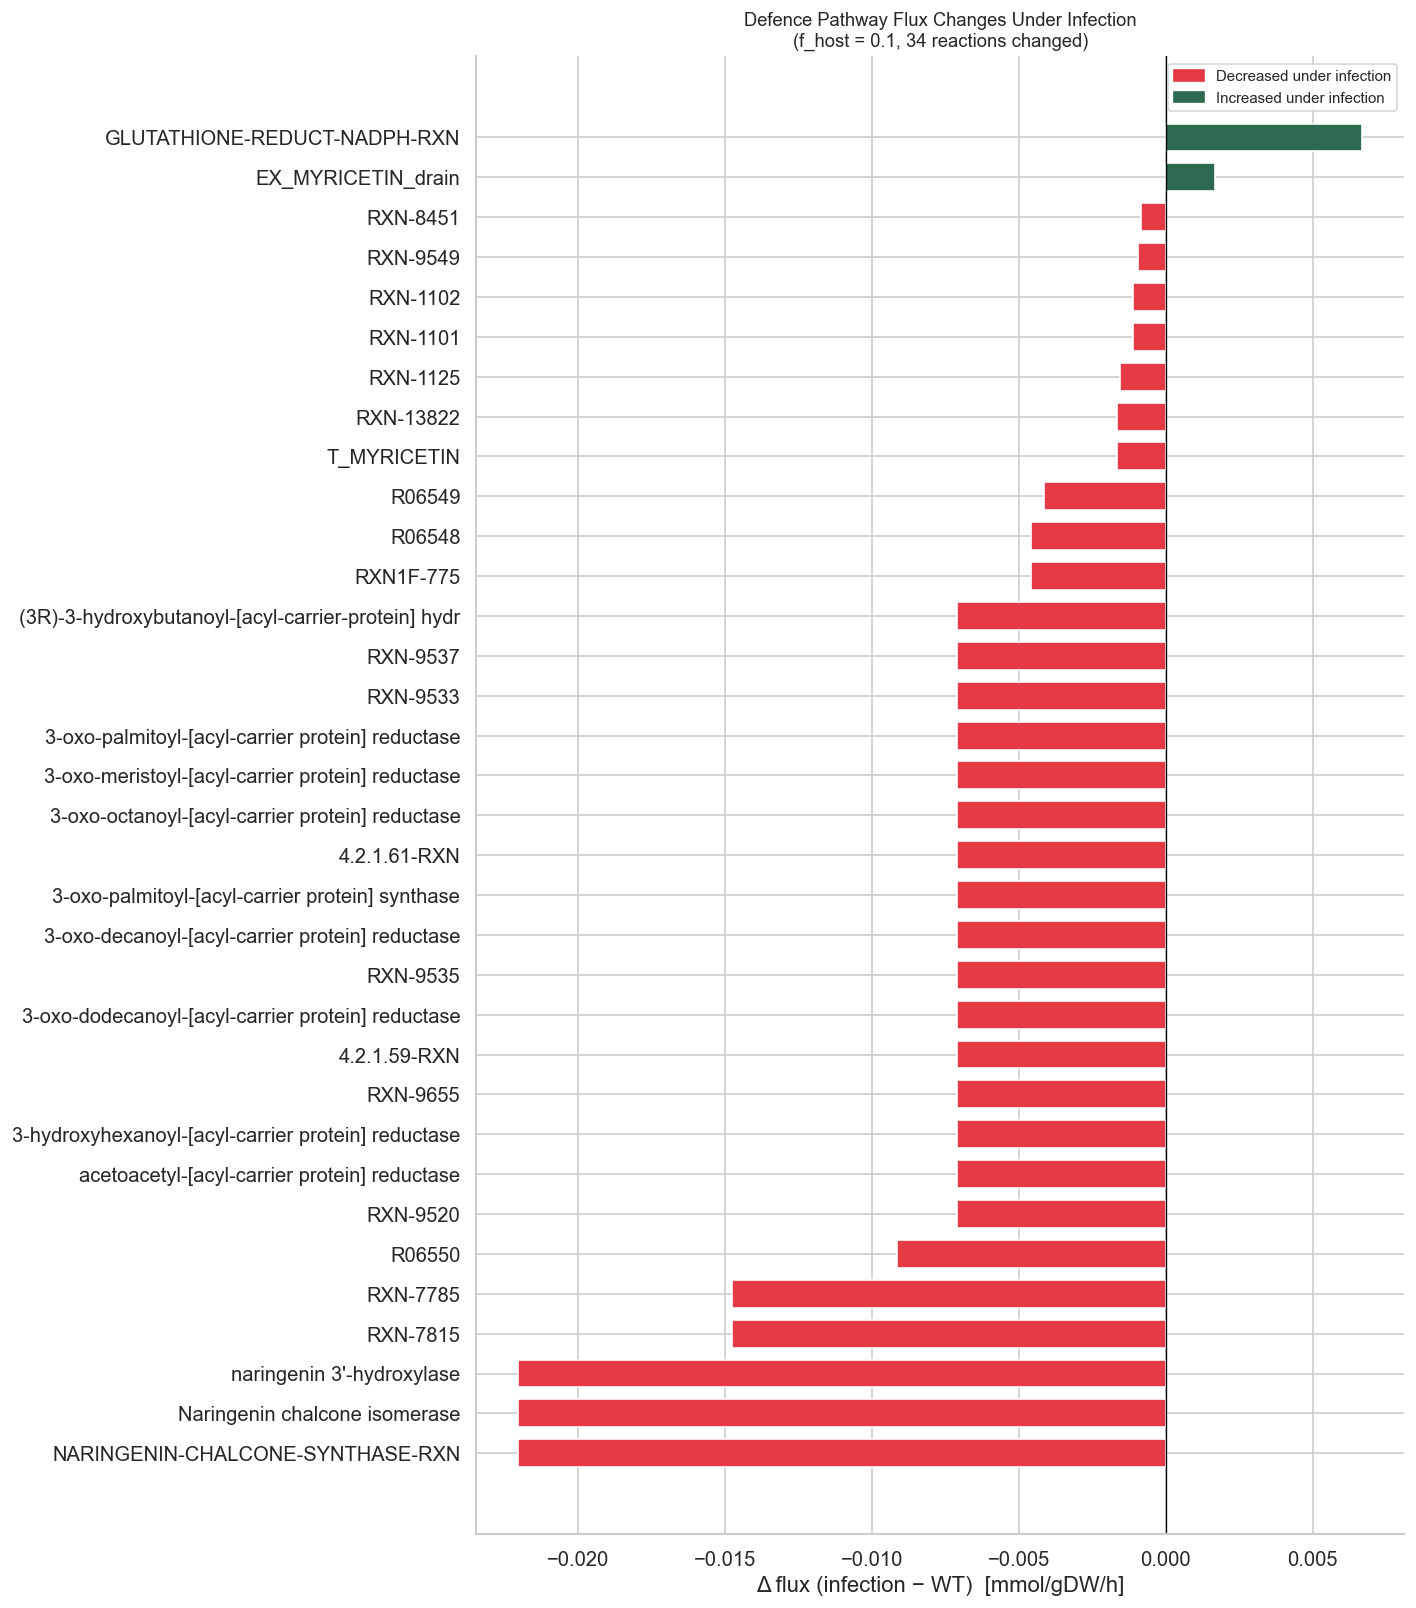

In [16]:
if len(df_defense) > 0 and 'df_def_flux' in dir():
    df_changed = df_def_flux[abs(df_def_flux['Delta']) > 1e-6].copy()
    df_changed = df_changed.sort_values('Delta')

    if len(df_changed) > 0:
        fig, ax = plt.subplots(figsize=(12, max(5, len(df_changed) * 0.4)))
        colors_d = [C_INF if d < 0 else C_GRAPE for d in df_changed['Delta']]
        bars = ax.barh(df_changed['Name'], 
                       df_changed['Delta'],
                       color     = colors_d, 
                       edgecolor = 'white', 
                       height    = 0.7)
        ax.axvline(0, color = 'black', lw = 0.8)
        ax.set_xlabel('Δ flux (infection − WT)  [mmol/gDW/h]')
        ax.set_title(f'Defence Pathway Flux Changes Under Infection\n'
                     f'(f_host = {F_HOST_PEAK:.1f}, {len(df_changed)} reactions changed)',
                     fontsize = 11)

        red_p  = mpatches.Patch(color = C_INF,   label = 'Decreased under infection')
        grn_p  = mpatches.Patch(color = C_GRAPE, label = 'Increased under infection')
        ax.legend(handles=[red_p, grn_p], fontsize=9)
        plt.tight_layout()
        # plt.savefig('fig4_defense_flux.png', dpi = 150, bbox_inches = 'tight')
        plt.show()
    else:
        print('No defence reactions change between WT and infection conditions.')

## 9. Stilbene / Resveratrol Pathway — Targeted Search

Resveratrol and ε-viniferin are the primary phytoalexins of *V. vinifera*, synthesised via the stilbene synthase (STS) branch of phenylpropanoid metabolism. A targeted search is performed regardless of flux status to confirm presence and map the pathway.

In [17]:
STILBENE_KEYWORDS = ['stilbene', 'resveratrol', 'viniferin', 'pinosylvin',
                     'RXN-8051', 'RXN-8052', 'STS', 'phenylalanine ammonia-lyase',
                     'cinnamate', '4-coumaroyl', 'malonyl', 'TRANS-RESVERATROL',
                     'RESVERATROL', 'VINIFERIN']

stilbene_rxns = []
for rxn in vv.reactions:
    txt = (rxn.name + ' ' + rxn.id + ' ' + rxn.subsystem).lower()
    for kw in STILBENE_KEYWORDS:
        if kw.lower() in txt:
            with vv:
                sol = vv.optimize()
                flux_wt = sol.fluxes.get(rxn.id, 0)
            stilbene_rxns.append({'ID'      : rxn.id,
                                  'Name'    : rxn.name[:55],
                                  'Subsystem': rxn.subsystem[:35],
                                  'Flux WT' : round(flux_wt, 6),
                                  'LB'      : rxn.lower_bound,
                                  'UB'      : rxn.upper_bound,
                                  'Status'  : 'active' if abs(flux_wt) > 1e-6 else 'blocked',})
            break

stilbene_mets = []
for met in vv.metabolites:
    txt = (met.name + ' ' + met.id).lower()
    for kw in STILBENE_KEYWORDS:
        if kw.lower() in txt:
            stilbene_mets.append({'ID'  : met.id, 'Name': met.name[:50]})
            break

df_stilbene = pd.DataFrame(stilbene_rxns)
df_stmets   = pd.DataFrame(stilbene_mets)

print(f'Stilbene/resveratrol reactions: {len(df_stilbene)}')
print(f'Stilbene/resveratrol metabolites: {len(df_stmets)}')

if len(df_stilbene) > 0:
    print('\nReactions:')
    print(df_stilbene.to_string(index=False))

if len(df_stmets) > 0:
    print('\nMetabolites:')
    print(df_stmets.to_string(index=False))

if len(df_stilbene) == 0 and len(df_stmets) == 0:
    print('\nNote: No stilbene reactions found by keyword.')
    print('iMS7199 uses BioCyc IDs — searching by metabolite formula C14H12O3 (resveratrol):')
    for met in vv.metabolites:
        if met.formula and 'C14H12O3' in (met.formula or ''):
            print(f'  {met.id} — {met.name}')
            for rxn in met.reactions:
                print(f'    {rxn.id}: {rxn.name[:50]}')

Stilbene/resveratrol reactions: 18
Stilbene/resveratrol metabolites: 35

Reactions:
                                       ID                                Name                           Subsystem  Flux WT        LB       UB  Status
                          RXN-12297__cyto                           RXN-12297 detoxification of reactive carbonyl 0.000000       0.0 100000.0 blocked
                          RXN-12297__mito                           RXN-12297 detoxification of reactive carbonyl 0.000000       0.0 100000.0 blocked
                          RXN-12297__chlo                           RXN-12297 detoxification of reactive carbonyl 0.000000       0.0 100000.0 blocked
                          RXN-11002__mito                           RXN-11002 crotonyl-CoA/ethylmalonyl-CoA/hydro 0.000000       0.0 100000.0 blocked
                          RXN-11002__cyto                           RXN-11002 crotonyl-CoA/ethylmalonyl-CoA/hydro 0.000000       0.0 100000.0 blocked
  CINNAMATE-GLUC

## 10. Conclusion

### 10.1 Mycotoxin Pathway Coverage in *iJB1325*

The *iJB1325* reconstruction contains complete biosynthetic routes for OTA and kotanin, including PKS reactions, secretion transporters, and OTA hydrolysis (fungal self-detoxification). Fumonisin B-series metabolites are present as model entities but lack associated reactions. This limits fumonisin analysis to the metabolite presence/absence level. Additionally, fonsecinones A/B/C, funalenone, and FK17-P2a were identified as further polyketide secondary metabolites in *iJB1325*, extending the known secondary metabolism inventory of the model.

### 10.2 Growth–Virulence Tradeoff

Neither OTA nor kotanin are produced at maximum growth: all mycotoxin pathway fluxes are zero when the biomass objective is maximised. This is consistent with the well-established observation that *A. niger* mycotoxin production is induced by nitrogen or carbon limitation, not under optimal growth conditions.

When secretion is forced, both toxins impose a linear metabolic cost: **kotanin is more expensive per unit secreted than OTA** — $47.4\%$ vs. $36.5\%$ growth penalty per $0.1$ mmol/gDW/h of secretion — reflecting the higher precursor investment of the bis-coumarin structure relative to the OTA polyketide–amino acid hybrid.

### 10.3 Nutrient Environment Determines Mycotoxin Capacity

Under the infection-simulated nutrient medium (T1 leakage composition), the maximum OTA secretion capacity is **$0.6818 mmol/gDW/h$** — $25\%$ of the capacity achievable in the rich synthetic standard medium ($2.7273 mmol/gDW/h$). This reduction reflects the narrower nutrient diversity of the infection environment: the standard *iJB1325* medium provides a broad range of carbon, nitrogen, and cofactor sources, whereas the infection medium is dominated by citrate, phosphate, sugars, and a limited amino acid set.

Supplementing phenylalanine (a direct OTA precursor with shadow price = $−0.184$) did not increase OTA capacity, confirming that PHE is not the sole bottleneck — multiple co-factors and precursors are simultaneously limiting in the infection medium. The OTA capacity of $0.6818 mmol/gDW/h$ thus represents the mycotoxin production potential specifically enabled by host leakage, irrespective of PHE availability.

### 10.4 Host Nutrients as Growth Subsidy

The incremental growth analysis reveals a clear hierarchy of infection nutrient importance:

| Nutrient added cumulatively | μ (h⁻¹) | Key finding |
|---|---|---|
| None | $0.000 $| No growth without external carbon/phosphate |
| + Glucose | $0.102$ | Basic fermentable carbon |
| + Fructose | $0.176$ | Additional hexose |
| + Citrate | $0.428$ | Major energy/carbon source for *A. niger* |
| + **Phosphate** | **$0.984$** | **Single most limiting nutrient (+0.556 h⁻¹)** |
| + Malate, Glutamate, Proline, Serine | $1.119 $| Exceeds standard medium μ_max ($0.940$ h⁻¹) |

**Phosphate is the dominant infection nutrient** — its addition alone ($0.556 h⁻¹$) is comparable to all remaining nutrients combined ($0.563 h⁻¹$) — making phosphate by far the single most critical infection nutrient. This directly confirms the finding that phosphate is the second most important T1 metabolite by flux ($13.3 mmol/gDW/h$ cytoplasmic proxy). The full infection nutrient mixture supports **$19\%$ higher growth than the standard synthetic medium**, demonstrating that the host metabolic environment during infection provides a richer substrate than the baseline model medium — the host actively subsidises pathogen fitness.

### 10.5 Host Defence Suppression

Of $156$ defence-related reactions in *iMS7199*, $32$ carry non-zero flux at baseline. Under infection conditions (f_host = $0.10$, $90\%$ suppression), **31 of 32 active defence reactions decrease**, with naringenin biosynthesis (`NARINGENIN-CHALCONE-SYNTHASE-RXN`) and anthocyanin reactions (`RXN-7785`, `RXN-7815`) showing the largest reductions. The sole exception is chloroplastic glutathione reductase (`GLUTATHIONE-REDUCT-NADPH-RXN__chlo`, $+0.007$), which increases — consistent with an oxidative stress response to infection.

Critically, **resveratrol biosynthesis (`RXN-87`) is structurally blocked** in the mature berry model (flux = $0$, lb = $0$). This confirms and extends the finding that stilbene biosynthesis is structurally blocked in the *iMS7199* mature berry model. The metabolite *trans*-resveratrol (CPD-83) is present in the model but cannot be produced — the primary phytoalexin defence of *V. vinifera* is unavailable precisely when *A. niger* infection risk is highest.

A second reaction, `EX_MYRICETIN_drain`, also increases under infection ($+0.00167 mmol/gDW/h$). However, this is a direct FBA flux redistribution artefact: `RXN-13822` (myricetin gentiobioside biosynthesis, the main myricetin sink at baseline) decreases by exactly the same magnitude ($−0.00167$), and `T_MYRICETIN__cyto` runs in reverse ($−0.00167$), closing the flux balance. The three values are identical, confirming that the drain activation reflects solver rerouting under the capped biomass constraint and carries no independent biological significance.

## 11. Limitations

- **FBA maximises growth, not toxin production.** The growth–virulence tradeoff reflects a theoretical capacity, not a predicted *in vivo* production rate. Transcriptional regulation of PKS genes and nitrogen catabolite repression are not captured.
- **Fumonisin biosynthesis is incomplete in iJB1325.** The metabolites exist but the pathway is absent; fumonisin risk cannot be quantified within this framework.
- **PHE bottleneck is multi-factorial.** Shadow price analysis identifies PHE as limiting, but the infection medium imposes simultaneous constraints on multiple precursors; single-nutrient supplementation is insufficient to shift OTA capacity.
- **OTA–host interaction at the molecular level** (phenylalanyl-tRNA interference, nephrotoxic mechanism) operates at the protein level and is outside the scope of constraint-based modelling.

## 12. References

* **iJB1325** (Brandl et al., 2018)

Brandl, J., Aguilar-Pontes, M. V., Schäpe, P., Nørregaard, A., Arvas, M., Ram, A. F. J., Meyer, V., Tsang, A., de Vries, R. P., & Andersen, M. R. (2018). A community-driven reconstruction of the *Aspergillus niger* metabolic network. *Fungal Biology and Biotechnology*, *5*, 16. https://doi.org/10.1186/s40694-018-0060-7

* **iMS7199** (Sampaio, M., Rocha, M., & Dias, O., 2024)

Sampaio, M., Rocha, M., & Dias, O. (2024). iMS7199 – genome-scale metabolic model of *Vitis vinifera* (Model ID MODEL2408120001). [Data set]. BioModels. https://biomodels.org/MODEL2408120001